## Цели и задачи

Выявить закономерности, определяющие успешность игры, с целью сделать ставку на потенциально популярный продукт и спланировать рекламные кампании. В датасете есть исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation)

### Изучение общей информации

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
df = pd.read_csv('games_data.сsv', sep='\t')

In [4]:
df.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,"2,006.00",Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,"1,985.00",Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,"2,008.00",Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,"2,009.00",Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,"1,996.00",Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,"1,989.00",Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,"2,006.00",Platform,11.28,9.14,6.50,2.88,89.00,8.5,E
7,Wii Play,Wii,"2,006.00",Misc,13.96,9.18,2.93,2.84,58.00,6.6,E
8,New Super Mario Bros. Wii,Wii,"2,009.00",Platform,14.44,6.94,4.70,2.24,87.00,8.4,E
9,Duck Hunt,NES,"1,984.00",Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB


Комментарии по датасету:
* В названии столбцов присутствует верхний регистр, приводим все названия столбцов к нижнему регистру.
* Год предпочтительно перевести в целочисленный тип.
* user_score: 'tbd' предлагаю заменить на 'nan', смысл похожий. tbd = "To Be Determined", т.е. показатель будет определен позже.
* user_score пререводим в тип float, т.к. оценка представлена не целым числом, а для анализа успешности игры скорее всего придется считать среднее/медиану.
* У большого количества игр отсутствует оценка критиков/пользователей/рейтинг. Анализ успешности таких игр делаем на оновании продаж
* Пропуски (Nan) в оценках критиков и пользователей оставляю без изменений. Сильных выбросов в данных нет, можно будет сравнить среднее и медианное значения. По умолчанию при подсчете среднего и медианного значений Nan будет игнорироваться. Если заменить на нули, то будут искажены среднее и медианное значения. 
* Почему есть пропуски в оценках зрителей и пользователей? Была проведена группировка по платформам, жанрам, годам с подсчетом количества игр с пропущенными/не пропущенными оценками в каждой группе.
    * Было предположение, что игры стали получать оценки с определенного года - это предположение оправдалось: игры в датасете начинаются с 1980 года, а оценки стали активно появляться с 1996.
    * Часть пропусков с оценками связано с тем, что не для всех платформ ставятся оценки. Оценки проставлены для 17 платформ из 31
    * По жанрам закономерности в пропусках не выявлено, из 12 жанров для всех есть как игры с оценками, так и игры с пропущенными оценками.

array([[<Axes: title={'center': 'Year_of_Release'}>,
        <Axes: title={'center': 'NA_sales'}>],
       [<Axes: title={'center': 'EU_sales'}>,
        <Axes: title={'center': 'JP_sales'}>],
       [<Axes: title={'center': 'Other_sales'}>,
        <Axes: title={'center': 'Critic_Score'}>]], dtype=object)

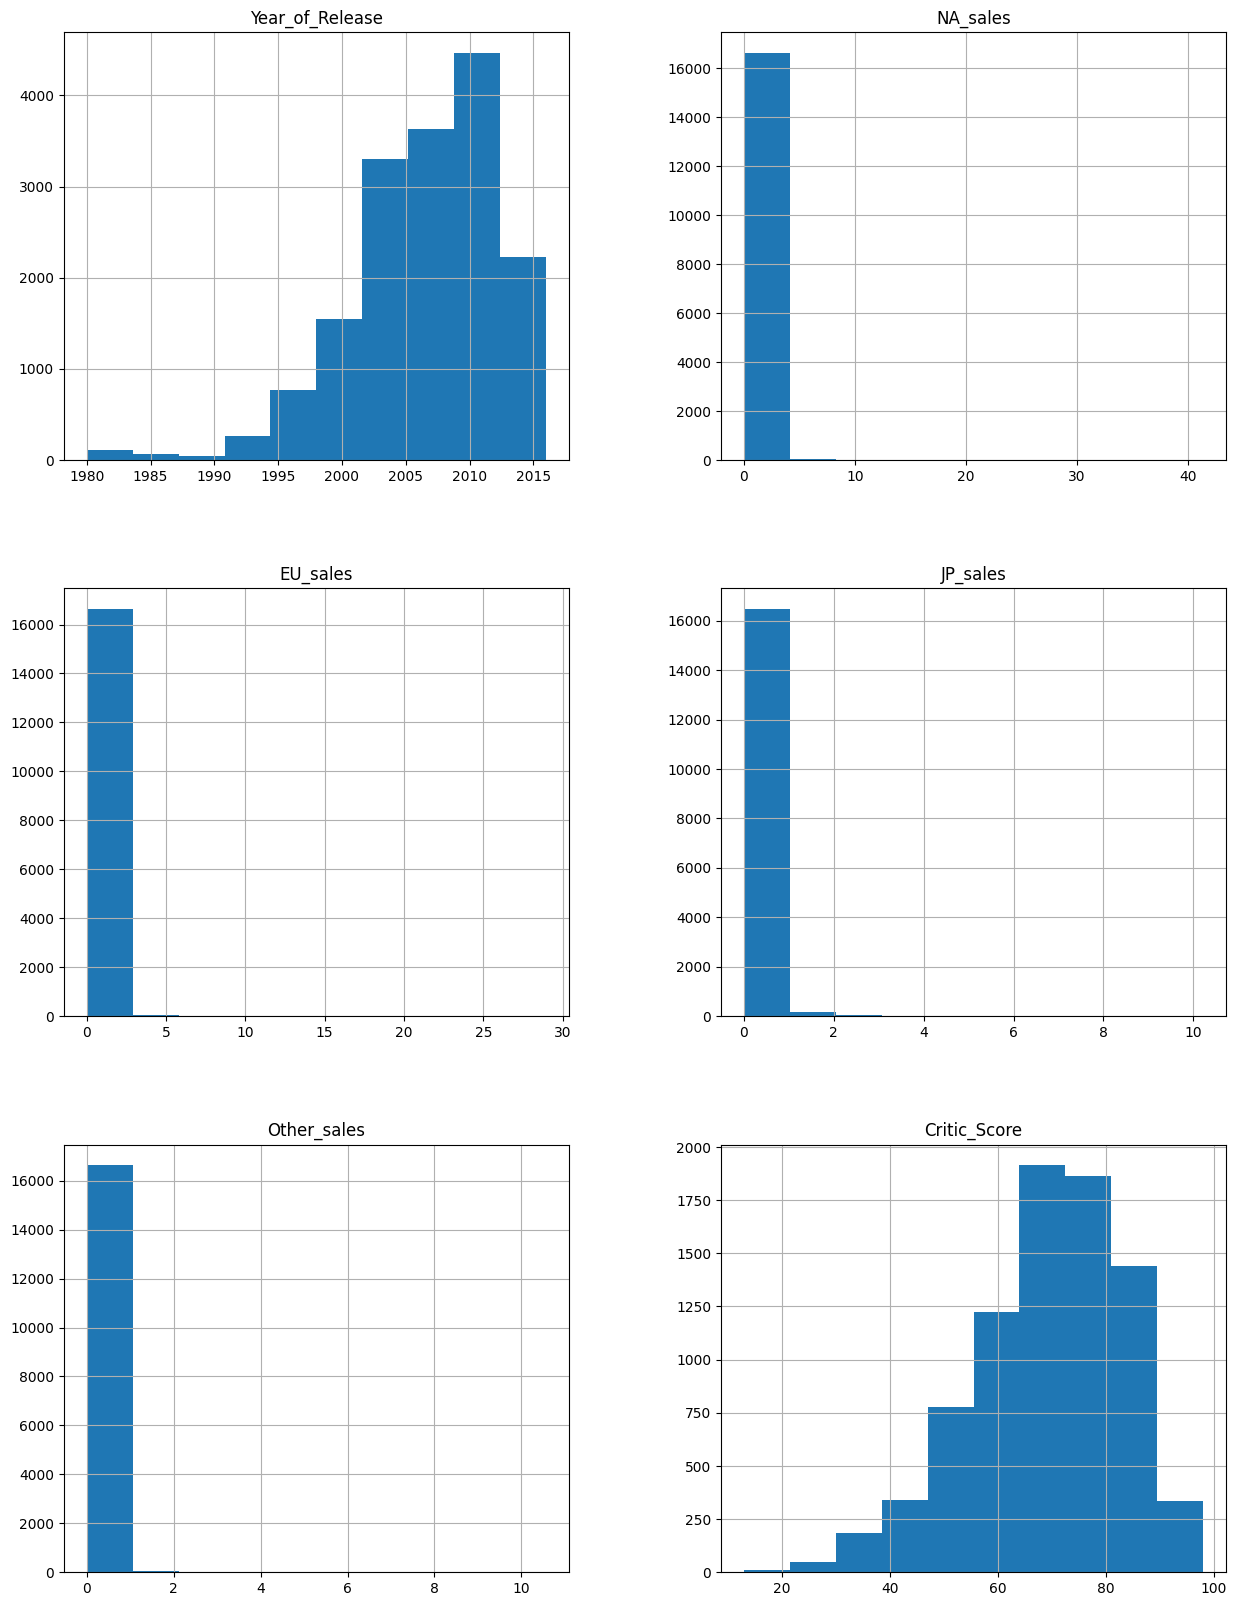

In [6]:
df.hist(figsize=(15, 20))

### Подготовка данных

#### Замените названия столбцов (приведите к нижнему регистру)

In [7]:
df.columns = [x.lower() for x in df.columns]
# data.columns = data.columns.str.lower()

#### Убираем дробную часть в столбце 'year_of_release'

In [8]:
df['year_of_release'] = df['year_of_release'].astype('Int16')

#### Замена пропусков в 'user_score' на Nan приведение 'user_score' к типу float

In [9]:
df['user_score'] = df['user_score'].replace('tbd', np.nan)

In [10]:
df['user_score'] = df['user_score'].astype(float)

#### Добавление столбца 'total_sales'

In [11]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  Int16  
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
 11  total_sales      16715 non-null  float64
dtypes: Int16(1), float64(7), str(4)
memory usage: 1.5 MB


#### Почему есть пропуски в оценках зрителей и пользователей?

In [13]:
df[~df['critic_score'].isna()].groupby('year_of_release')['year_of_release'].count()

year_of_release
1985      1
1988      1
1992      1
1994      1
1996      8
1997     17
1998     28
1999     39
2000    143
2001    326
2002    627
2003    585
2004    561
2005    655
2006    620
2007    692
2008    715
2009    651
2010    500
2011    500
2012    321
2013    273
2014    261
2015    225
2016    232
Name: year_of_release, dtype: Int64

Активно стали появляться оценки с 1996 года, хотя игры в датасете с 1980 года.

In [14]:
df[~df['critic_score'].isna()].groupby('platform')['platform'].count().count()

np.int64(17)

In [15]:
df.groupby('platform')['platform'].count().count()

np.int64(31)

Оценки есть для 17 платформ из 31

In [16]:
df[~df['critic_score'].isna()].groupby('genre')['genre'].count().count()

np.int64(12)

In [17]:
df.groupby('genre')['genre'].count().count()

np.int64(12)

Оценки есть для всех жанров

Почему есть пропуски в оценках зрителей и пользователей? Была проведена группировка по платформам, жанрам, годам с подсчетом количества игр с пропущенными/не пропущенными оценками в каждой группе.
* Было предположение, что игры стали получать оценки с определенного года - это предположение оправдалось: игры в датасете начинаются с 1980 года, а оценки стали активно появляться с 1996.
* Часть пропусков с оценками связано с тем, что не для всех платформ ставятся оценки. Оценки проставлены для 17 платформ из 31
* По жанрам закономерности в пропусках не выявлено, из 12 жанров для всех есть как игры с оценками, так и игры с пропущенными оценками.

Ищем неявные дубликаты

In [18]:
df[df.duplicated(subset=['name','platform']) == True]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
1591,Need for Speed: Most Wanted,X360,2005,Racing,1.00,0.13,0.02,0.10,83.00,8.50,T,1.25
4127,Sonic the Hedgehog,PS3,<NA>,Platform,0.00,0.48,0.00,0.00,43.00,4.10,E10+,0.48
11715,Need for Speed: Most Wanted,PC,2012,Racing,0.00,0.06,0.00,0.02,82.00,8.50,T,0.08
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN,0.03
16230,Madden NFL 13,PS3,2012,Sports,0.00,0.01,0.00,0.00,83.00,5.50,E,0.01


Удаляем дубликаты

In [19]:
df = df.drop(df[df.duplicated(subset=['name','platform']) == True].index)

### Исследовательский анализ данных

In [20]:
df.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.00,8.00,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.00,8.30,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.00,8.00,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN,30.26
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.00,8.50,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.00,6.60,E,28.91
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.00,8.40,E,28.32
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN,28.31


#### Динамика выпуска игр в разные годы

<Axes: >

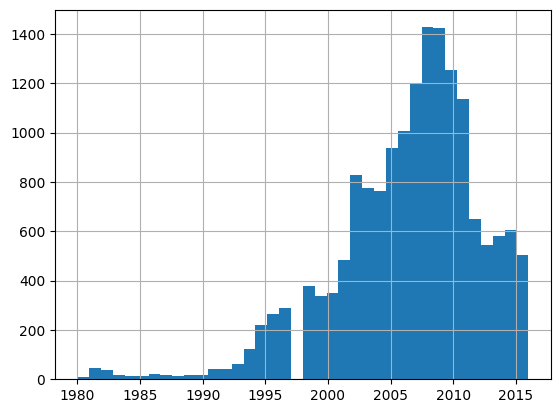

In [21]:
df['year_of_release'].hist(bins=38)

Данные за периоды интересны тем, что:
* Во-первых, наблюдаются всплески по количеству выпущенны игр. Есть подозрение что это связано с выпуском новых популярных платформ от MS и Sony
* Во-вторых, виден спад в выпуске игра за период с 2010 по 2015 год.

#### Исследование продаж по платформам

In [22]:
df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10)

platform
PS2    1,255.77
X360     970.17
PS3      939.16
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.44
Name: total_sales, dtype: float64

Среди самых популярных платформ по суммарным продажам выделяем: PS2, X360, PS3, Wii, DS, PS.
Строим графики, чтобы посмотреть на срок жизни популярных платформ

<Axes: xlabel='year_of_release'>

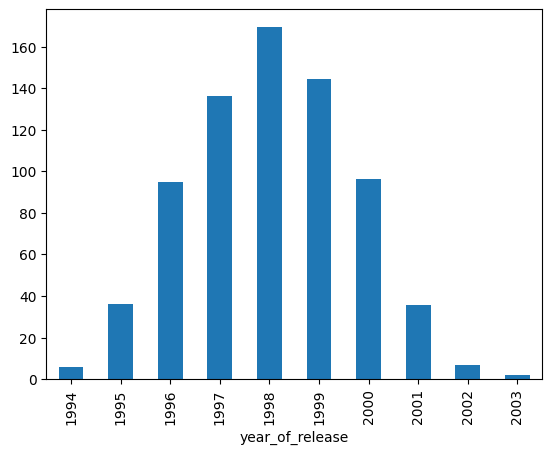

In [23]:
df[df['platform'] == 'PS'].groupby('year_of_release')['total_sales'].sum().plot(kind='bar')

<Axes: xlabel='year_of_release'>

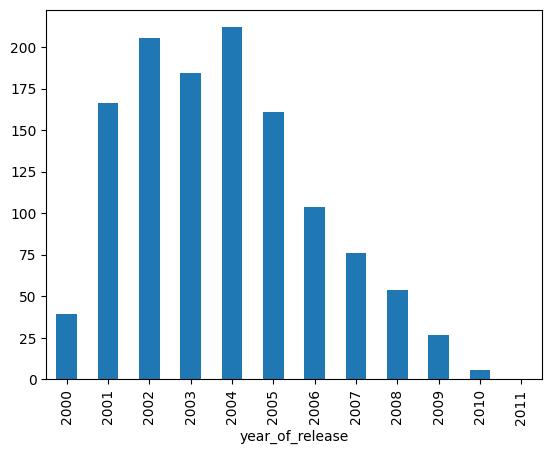

In [24]:
df[df['platform'] == 'PS2'].groupby('year_of_release')['total_sales'].sum().plot(kind='bar')

<Axes: xlabel='year_of_release'>

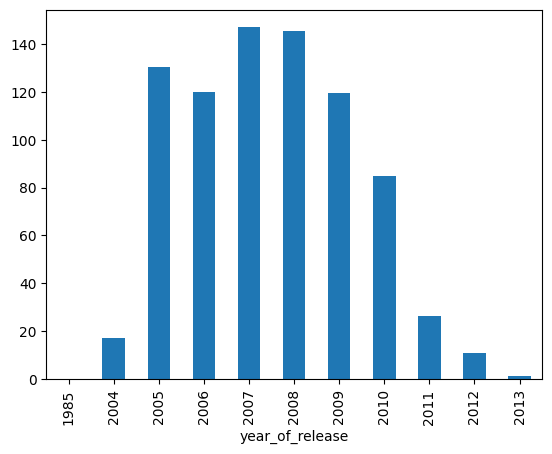

In [25]:
df[df['platform'] == 'DS'].groupby('year_of_release')['total_sales'].sum().plot(kind='bar')

<Axes: xlabel='year_of_release'>

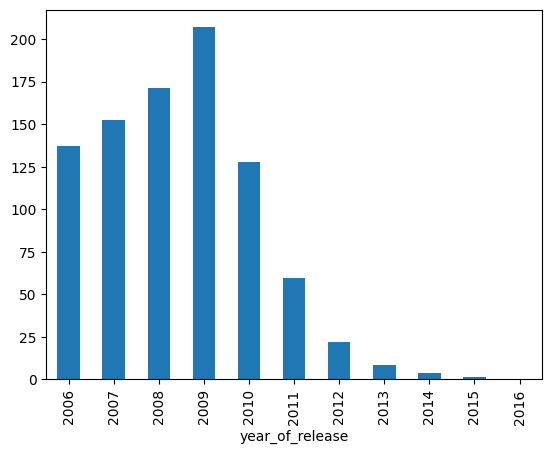

In [26]:
df[df['platform'] == 'Wii'].groupby('year_of_release')['total_sales'].sum().plot(kind='bar')

<Axes: xlabel='year_of_release'>

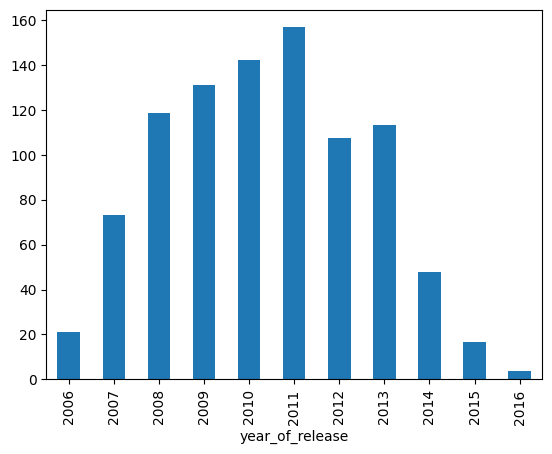

In [27]:
df[df['platform'] == 'PS3'].groupby('year_of_release')['total_sales'].sum().plot(kind='bar')

<Axes: xlabel='year_of_release'>

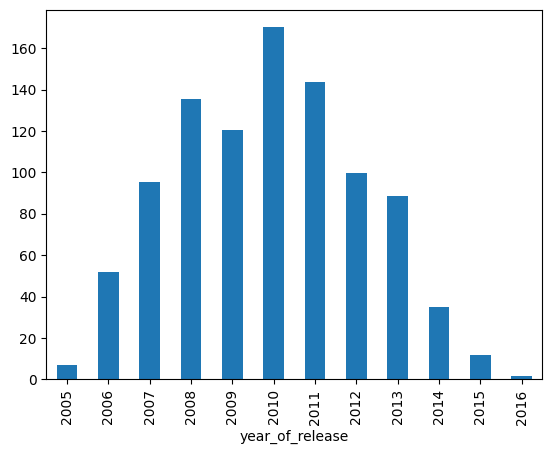

In [28]:
df[df['platform'] == 'X360'].groupby('year_of_release')['total_sales'].sum().plot(kind='bar')

Из графиков можно сделать следующий вывод:
* срок активной жизни платформы, период в который выпускается основное количетво игры для нее, составляет 5-6 лет.
* На примере платформы PS видно, что раз в 6 лет компания выпускает новую игровую платфому.
* Периодические пики на графике с общим количеством релизов игр можно объянить пиком выпуска игр для нескольких популярных платформ (пик по разным популярным платформам приходится на один период, т.к. чаще всего это прямые конкуренты). Например пик выпуска игр 2010-2011 приходится на период максимальной популярности платформ PS3 и X360 (пик цикла жизни этих платформ).

График количества релизов по годам

<Axes: >

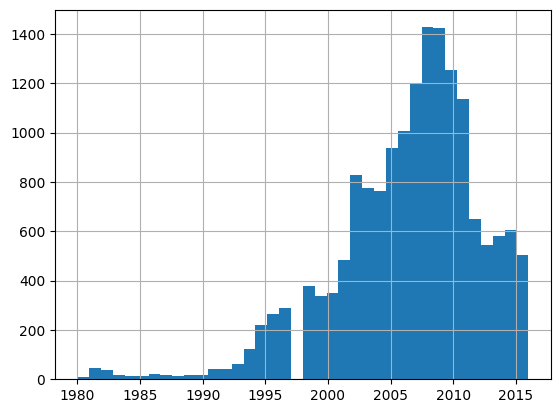

In [29]:
df['year_of_release'].hist(bins=38)

In [30]:
df[df['year_of_release'] == 2011].groupby('platform')['name'].count()

platform
3DS     116
DS      153
PC      139
PS2       7
PS3     215
PSP     139
PSV      18
Wii     143
X360    206
Name: name, dtype: int64

In [31]:
df[df['year_of_release'] == 2015].groupby('platform')['name'].count()

platform
3DS      86
PC       50
PS3      73
PS4     137
PSP       3
PSV     110
Wii       4
WiiU     28
X360     35
XOne     80
Name: name, dtype: int64

На графике с общим количеством релизов игр по годам виден провал с 2011 по 2014 год. Падение связано со сменой поколений в платформах Sony и MS, выпуск игр для предыдущего поколения идет на спад, новое поколение только набирает популярность. К 2015-2016 году новое поколение выходит на пик выпуска игр. Разница между пиками 2011 и 2015 годов обусловлена тем, что в 2011 году было больше популярных платформ (3DS, DS, Wii, PC3, X360, PSP), которые к 2015-2016 году потеряли свою актуальность, но им на смену не пришли новые поколения.
Для прогноза на 2017 год рассматриваем продажи за последние 5 лет.

#### Анализ продаж платформ в актуальном периоде

In [32]:
df_actual = df.query('year_of_release >= 2012')

In [33]:
df_actual.groupby('platform')['total_sales'].sum()

platform
3DS    194.61
DS      12.55
PC      62.57
PS3    288.78
PS4    314.14
PSP     11.19
PSV     49.18
Wii     35.37
WiiU    82.19
X360   236.54
XOne   159.32
Name: total_sales, dtype: float64

<Axes: xlabel='year_of_release'>

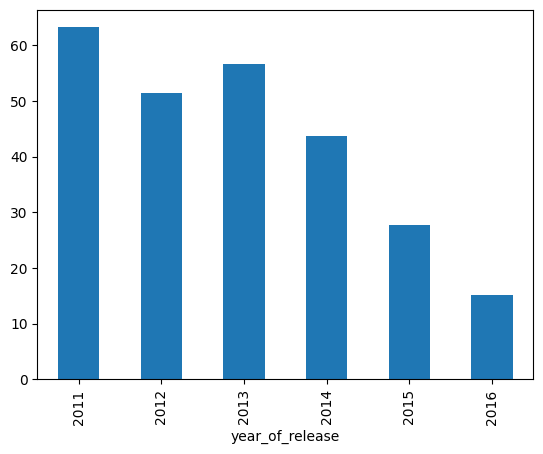

In [34]:
df[df['platform'] == '3DS'].groupby('year_of_release')['total_sales'].sum().plot(kind='bar')

<Axes: xlabel='year_of_release'>

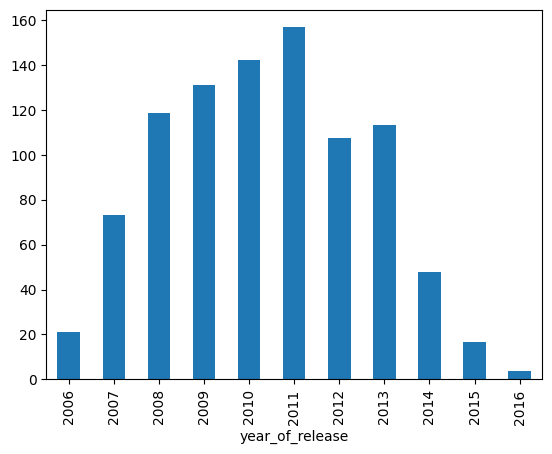

In [35]:
df[df['platform'] == 'PS3'].groupby('year_of_release')['total_sales'].sum().plot(kind='bar')

<Axes: xlabel='year_of_release'>

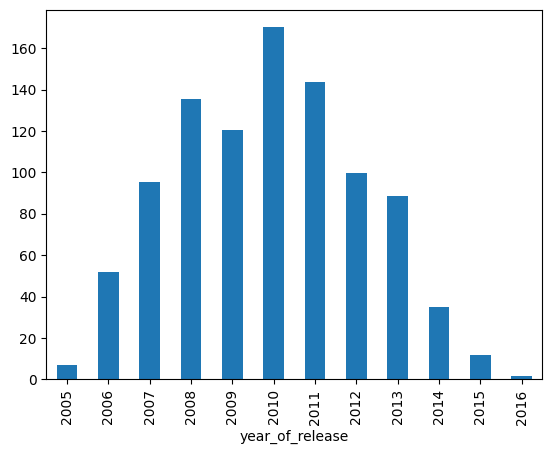

In [36]:
df[df['platform'] == 'X360'].groupby('year_of_release')['total_sales'].sum().plot(kind='bar')

<Axes: xlabel='year_of_release'>

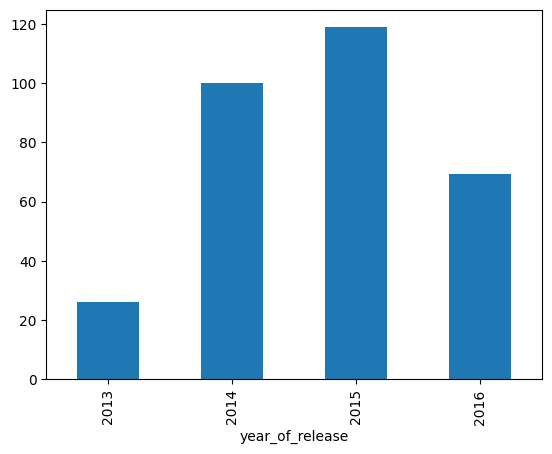

In [37]:
df[df['platform'] == 'PS4'].groupby('year_of_release')['total_sales'].sum().plot(kind='bar')

<Axes: xlabel='year_of_release'>

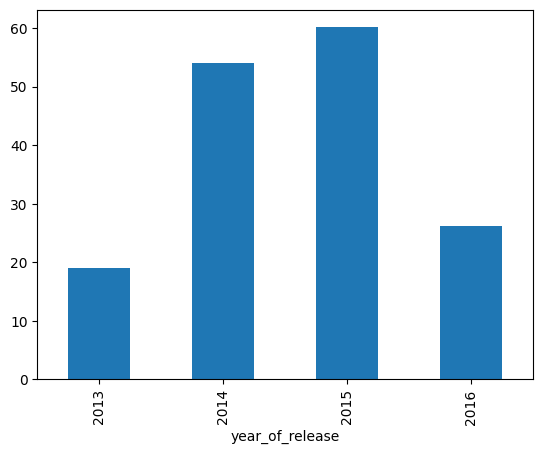

In [38]:
df[df['platform'] == 'XOne'].groupby('year_of_release')['total_sales'].sum().plot(kind='bar')

Лидерами продаж в актуальном периоде являются: 3DS, PS3, PS4, X360, XOne.
Как было замечено ранее в данном периоде идет смена поколений и ставку в 2017 году стоит сделать на новые платформы PS4 и XOne, которые будут набирать популярность. На графиках выше выидно, что в 2017 году будет "закат" 3DS, PS3, X360.

#### График «ящик с усами» по глобальным продажам игр в разбивке по платформам.

<Axes: title={'center': 'total_sales'}, xlabel='platform'>

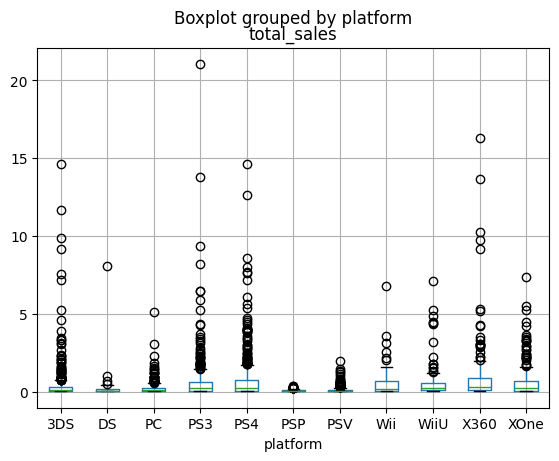

In [39]:
df_actual.boxplot(column='total_sales', by='platform')

Выбросы - это хиты и популярные релизы, которые генерируют основную выручку. Можно сказать, что почти для всех платформ большая часть выпускаемых игр не продается большим тиражом (медианное значения для всех платформ < 250 тыс. шт.). Есть небольшое количество хитов с продажами свыше 5 млн копий. Основное количество выбросов лежит в диапазоне от 0,5 млн до 5 млн - назовем их просто популярными играми.

(0.0, 2.0)

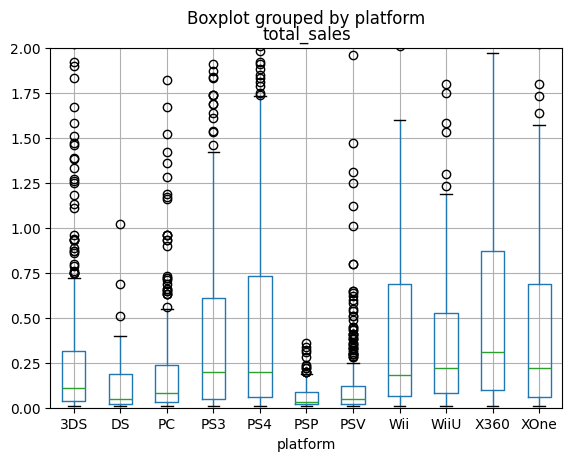

In [40]:
df_actual.boxplot(column='total_sales', by='platform').set_ylim([0, 2])

#### Исследование влияния отзывов на продажи платформы

Для исследования влияния отзывов пользователей и критиков на продажи игр возмем платформу PS4.

In [41]:
df_actual_PS4 = df_actual[df_actual['platform'] == 'PS4']
df_actual_PS4.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.00,8.30,M,12.62
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.00,4.30,E,8.58
87,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,NaN,7.98
92,Call of Duty: Advanced Warfare,PS4,2014,Shooter,2.81,3.48,0.14,1.23,83.00,5.70,M,7.66
94,FIFA 17,PS4,2016,Sports,0.66,5.75,0.08,1.11,85.00,5.00,E,7.60
105,Fallout 4,PS4,2015,Role-Playing,2.53,3.27,0.24,1.13,87.00,6.50,M,7.17
143,FIFA 15,PS4,2014,Sports,0.80,4.33,0.05,0.90,82.00,5.70,E,6.08
154,Destiny,PS4,2014,Shooter,2.49,2.07,0.16,0.92,76.00,6.10,T,5.64
171,Uncharted 4: A Thief's End,PS4,2016,Shooter,1.85,2.50,0.19,0.85,93.00,7.90,T,5.39


Text(0.5, 1.0, 'Влияние оценок критиков на продажи')

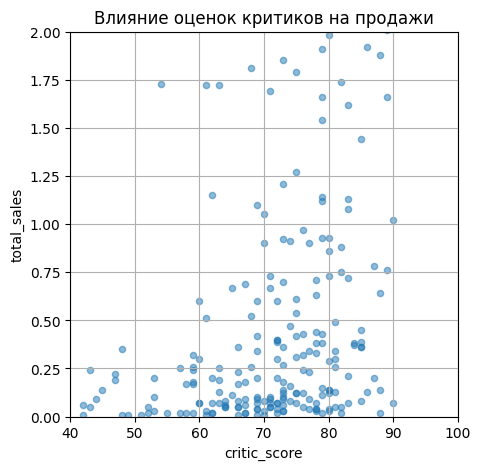

In [42]:
df_actual_PS4.plot(x='critic_score',
        y='total_sales',
        kind='scatter',
        xlim=(40, 100),
        ylim=(0, 2),
        figsize=(5,5),
        grid=True,
        alpha = 0.5
       )
plt.title('Влияние оценок критиков на продажи')

In [43]:
print(df_actual_PS4['critic_score'].corr(df_actual_PS4['total_sales']))

0.40656790206178095


Коэффициент корреляции Пирсона говорит, что есть слабая линейная зависимость между оценками критиков и продажами.

Text(0.5, 1.0, 'Влияние оценок пользователей на продажи')

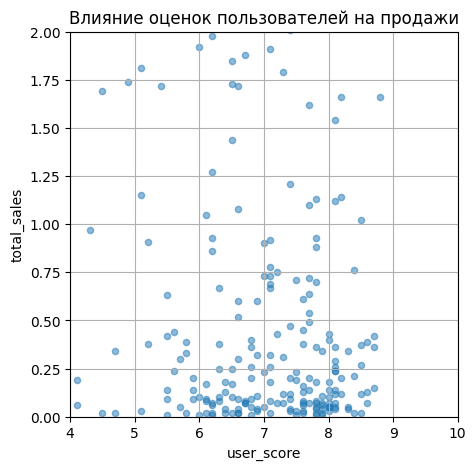

In [44]:
df_actual_PS4.plot(x='user_score',
        y='total_sales',
        kind='scatter',
        xlim=(4, 10),
        ylim=(0, 2),
        figsize=(5,5),
        grid=True,
        alpha = 0.5
       )
plt.title('Влияние оценок пользователей на продажи')

In [45]:
print(df_actual_PS4['user_score'].corr(df_actual_PS4['total_sales']))

-0.031957110204556376


Коэффициент корреляции Пирсона у оценок пользователей и продаж говорит, что парметры абсолютно не зависят друг от друга.

Для проверки нашей гипотезы, что между оценками и продажами нет корреляции, посмотрим на другую популярную платформу XOne 

In [46]:
df_actual_XOne = df_actual[df_actual['platform'] == 'XOne']
df_actual_XOne.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
99,Call of Duty: Black Ops 3,XOne,2015,Shooter,4.59,2.11,0.01,0.68,NaN,NaN,NaN,7.39
165,Grand Theft Auto V,XOne,2014,Action,2.81,2.19,0.00,0.47,97.00,7.90,M,5.47
179,Call of Duty: Advanced Warfare,XOne,2014,Shooter,3.22,1.55,0.01,0.48,81.00,5.40,M,5.26
242,Halo 5: Guardians,XOne,2015,Shooter,2.78,1.27,0.03,0.41,84.00,6.40,T,4.49
270,Fallout 4,XOne,2015,Role-Playing,2.51,1.32,0.01,0.38,88.00,6.20,M,4.22
342,Star Wars Battlefront (2015),XOne,2015,Shooter,2.04,1.28,0.02,0.32,NaN,NaN,NaN,3.66
373,Assassin's Creed: Unity,XOne,2014,Action,2.27,0.90,0.00,0.33,72.00,4.10,M,3.50
398,Destiny,XOne,2014,Shooter,2.14,0.92,0.00,0.31,75.00,5.50,T,3.37
413,Gears of War: Ultimate Edition,XOne,2015,Shooter,2.61,0.33,0.00,0.34,82.00,7.50,M,3.28
417,FIFA 16,XOne,2015,Sports,0.89,2.12,0.00,0.24,84.00,4.40,E,3.25


Text(0.5, 1.0, 'Влияние оценок критиков на продажи')

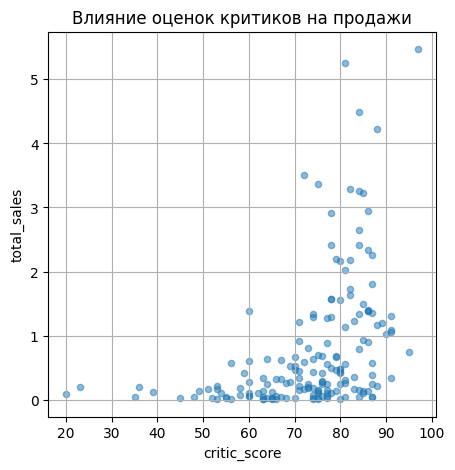

In [47]:
df_actual_XOne.plot(x='critic_score',
        y='total_sales',
        kind='scatter',
        figsize=(5,5),
        grid=True,
        alpha = 0.5
       )
plt.title('Влияние оценок критиков на продажи')

In [48]:
print(df_actual_XOne['critic_score'].corr(df_actual_XOne['total_sales']))

0.4169983280084017


Text(0.5, 1.0, 'Влияние оценок пользователей на продажи')

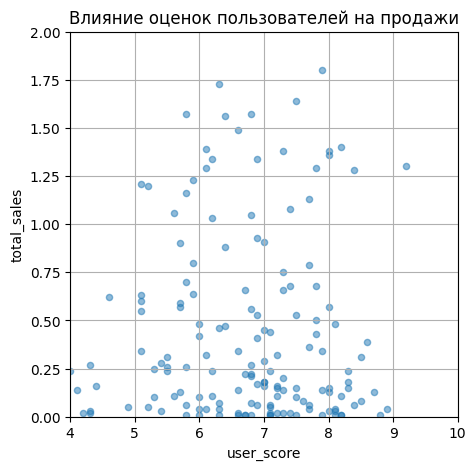

In [49]:
df_actual_XOne.plot(x='user_score',
        y='total_sales',
        kind='scatter',
        xlim=(4, 10),
        ylim=(0, 2),
        figsize=(5,5),
        grid=True,
        alpha = 0.5
       )
plt.title('Влияние оценок пользователей на продажи')

In [50]:
print(df_actual_XOne['user_score'].corr(df_actual_XOne['total_sales']))

-0.06892505328279414


Картина похожа на результат исследования платформы PS4.

In [51]:
df_actual_PS3 = df_actual[df_actual['platform'] == 'PS3']

Text(0.5, 1.0, 'Влияние оценок критиков на продажи')

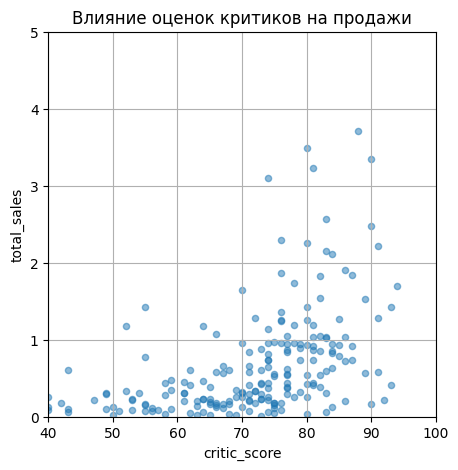

In [52]:
df_actual_PS3.plot(x='critic_score',
        y='total_sales',
        kind='scatter',
        figsize=(5,5),
        xlim=(40, 100),
        ylim=(0, 5),
        grid=True,
        alpha = 0.5
       )
plt.title('Влияние оценок критиков на продажи')

In [53]:
print(df_actual_PS3['critic_score'].corr(df_actual_PS3['total_sales']))

0.3341517575509856


Text(0.5, 1.0, 'Влияние оценок пользователей на продажи')

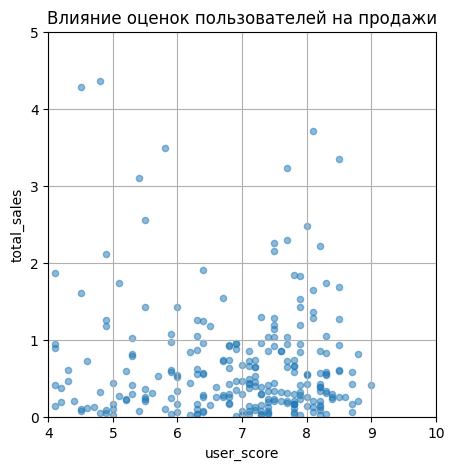

In [54]:
df_actual_PS3.plot(x='user_score',
        y='total_sales',
        kind='scatter',
        figsize=(5,5),
        xlim=(4, 10),
        ylim=(0, 5),
        grid=True,
        alpha = 0.5
       )
plt.title('Влияние оценок пользователей на продажи')

In [55]:
print(df_actual_PS3['user_score'].corr(df_actual_PS3['total_sales']))

-0.006205767686051523


---

In [56]:
df_actual_X360 = df_actual[df_actual['platform'] == 'X360']

Text(0.5, 1.0, 'Влияние оценок критиков на продажи')

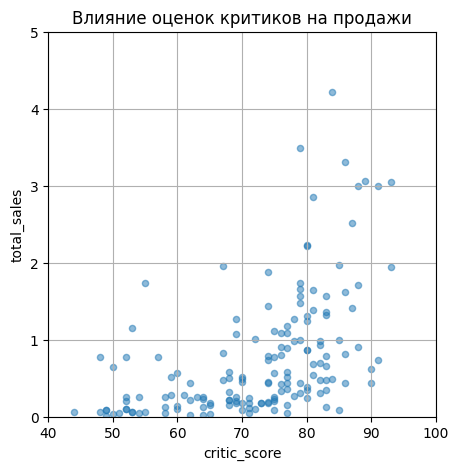

In [57]:
df_actual_X360.plot(x='critic_score',
        y='total_sales',
        kind='scatter',
        figsize=(5,5),                    
        xlim=(40, 100),
        ylim=(0, 5),        
        grid=True,
        alpha = 0.5
       )
plt.title('Влияние оценок критиков на продажи')

In [58]:
print(df_actual_X360['critic_score'].corr(df_actual_X360['total_sales']))

0.3605734888507336


Text(0.5, 1.0, 'Влияние оценок пользователей на продажи')

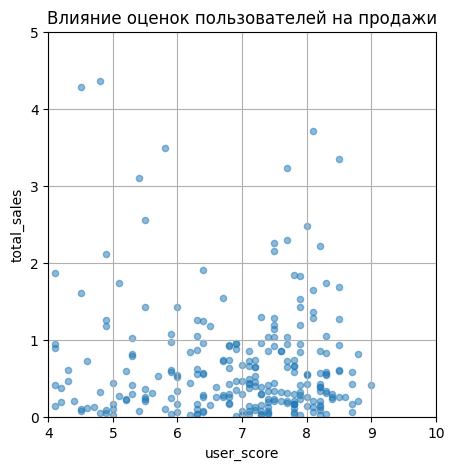

In [59]:
df_actual_PS3.plot(x='user_score',
        y='total_sales',
        kind='scatter',
        figsize=(5,5),
        xlim=(4, 10),
        ylim=(0, 5),
        grid=True,
        alpha = 0.5
       )
plt.title('Влияние оценок пользователей на продажи')

In [60]:
print(df_actual_X360['user_score'].corr(df_actual_X360['total_sales']))

0.006163978646213326


#### Распределение игр по жанрам

In [61]:
df_temp = df_actual.groupby('genre')['total_sales'].agg(['sum', 'mean', 'median']).sort_values(by='sum', ascending=False).reset_index()
df_temp

,genre,sum,mean,median
0,Action,441.12,0.43,0.12
1,Shooter,304.73,1.30,0.44
2,Role-Playing,192.80,0.52,0.14
3,Sports,181.06,0.68,0.24
4,Misc,85.04,0.44,0.12
5,Platform,61.00,0.72,0.21
6,Racing,53.42,0.47,0.15
7,Fighting,44.49,0.41,0.13
8,Simulation,35.12,0.44,0.12
9,Adventure,29.43,0.10,0.03


<Axes: xlabel='genre'>

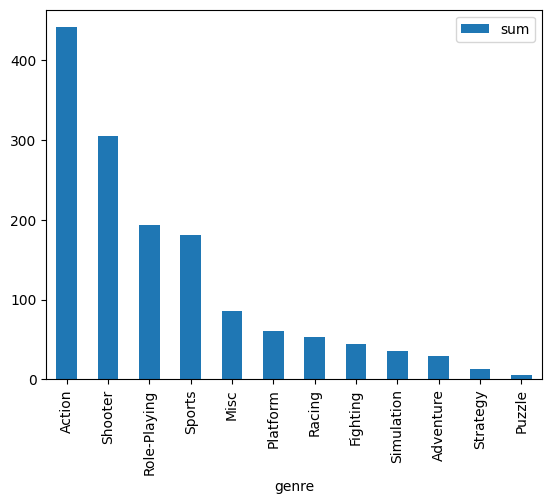

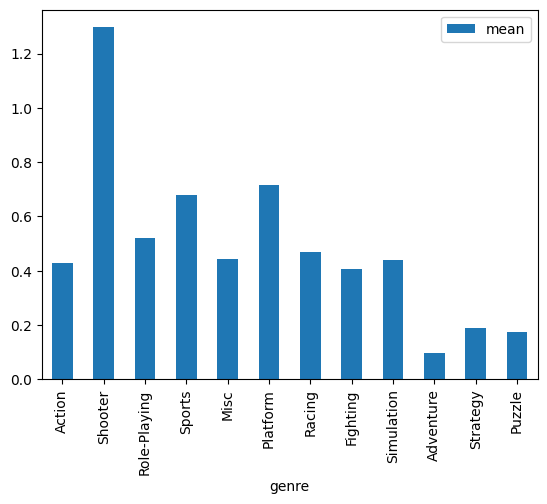

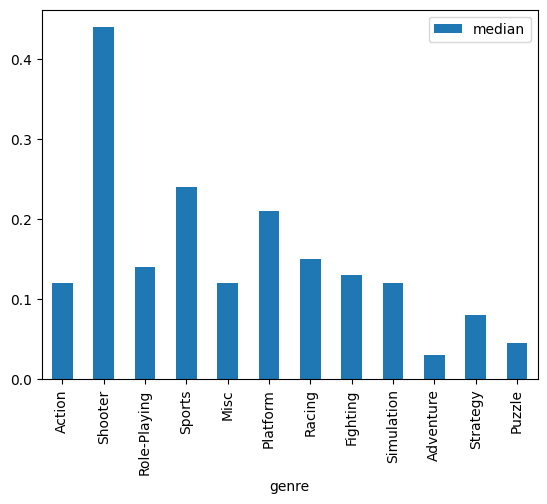

In [62]:
df_temp.plot(x='genre', y='sum', kind='bar')
df_temp.plot(x='genre', y='mean', kind='bar')
df_temp.plot(x='genre', y='median', kind='bar')

Самые популярные жанры по общим продажам: Action, Shooter, Role-Playing, Sports  
Самые непопулярные жанры по общим продажам: Puzzle, Strategy, Adventure, Simulation.

Если смотреть на средние продажи, то порядок самых продаваемых жанров меняется. Шансы хороших продаж в среднем больше у Shooter -> Platform -> Sports -> Role-Playing
Если смотреть на медианные значения по популярности меняются местами Platform и Sports

### Портрет пользователя каждого региона

#### Самые популярные платформы по регионам

In [63]:
df_top_platform = df_actual.pivot_table(index='platform',
                      values=['na_sales','eu_sales','jp_sales','other_sales'], 
                      aggfunc='sum', margins = True, margins_name='Total')

In [64]:
df_top_platform

,eu_sales,jp_sales,na_sales,other_sales
platform,,,,
3DS,42.64,87.79,55.31,8.87
DS,3.53,3.72,4.59,0.71
PC,37.70,0.00,19.12,5.75
PS3,106.85,35.29,103.38,43.26
PS4,141.09,15.96,108.74,48.35
PSP,0.42,10.47,0.13,0.17
PSV,11.36,21.04,10.98,5.80
Wii,11.92,3.39,17.45,2.61
WiiU,25.13,13.01,38.10,5.95


In [65]:
df_top_platform['eu_sales'] = df_top_platform['eu_sales'] / df_top_platform.loc['Total', 'eu_sales']
df_top_platform['jp_sales'] = df_top_platform['jp_sales'] / df_top_platform.loc['Total', 'jp_sales']
df_top_platform['na_sales'] = df_top_platform['na_sales'] / df_top_platform.loc['Total', 'na_sales']
df_top_platform['other_sales'] = df_top_platform['other_sales'] / df_top_platform.loc['Total', 'other_sales']

In [66]:
df_top_platform.reset_index()

,platform,eu_sales,jp_sales,na_sales,other_sales
0,3DS,0.08,0.46,0.09,0.06
1,DS,0.01,0.02,0.01,0.00
2,PC,0.07,0.00,0.03,0.04
3,PS3,0.21,0.18,0.17,0.28
4,PS4,0.28,0.08,0.18,0.31
5,PSP,0.00,0.05,0.00,0.00
6,PSV,0.02,0.11,0.02,0.04
7,Wii,0.02,0.02,0.03,0.02
8,WiiU,0.05,0.07,0.06,0.04
9,X360,0.15,0.01,0.24,0.13


(0.0, 0.5)

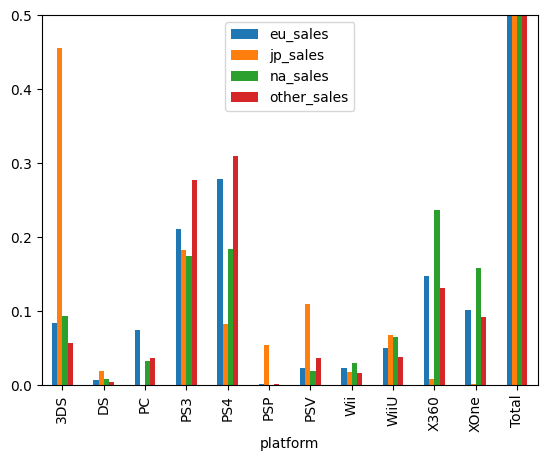

In [67]:
df_top_platform.plot(kind='bar').set_ylim([0, 0.5])

(0.0, 0.5)

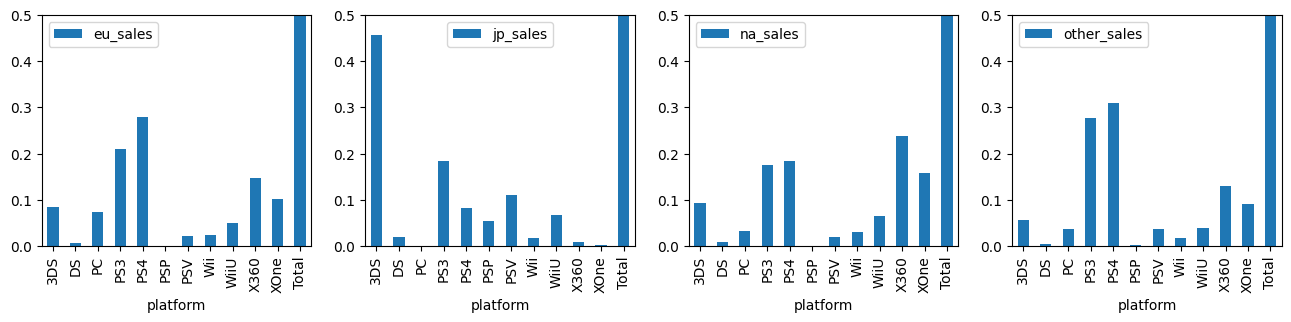

In [68]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16,3))
df_top_platform.plot(kind='bar', y='eu_sales', ax=axes[0]).set_ylim([0, 0.5])
df_top_platform.plot(kind='bar', y='jp_sales', ax=axes[1]).set_ylim([0, 0.5])
df_top_platform.plot(kind='bar', y='na_sales', ax=axes[2]).set_ylim([0, 0.5])
df_top_platform.plot(kind='bar', y='other_sales', ax=axes[3]).set_ylim([0, 0.5])

Топ платформы по регионам:
* EU: PS4, PS3, X360, XOne, 3DS
* JP: 3DS, PS3, PSV, PS4, WiiU 
* NA: X360, PS4, PS3, XOne, 3DS
* Other: PS4, PS3, X360, XOne, 3DS
Разница в предпочтениях пользователей связана с исторически сложившимися позициями платформ на местных рынках и особенностями предпочтений пользователей конкретного региона:
* платформа Xbox от американского производителя, чаще всего доминирует на местном рынке (NA)
* Европейцы больше предпочитают продукцию Sony
* Японцам больше нравятся мобильные платформы 3DS, PSV, PSP и платформы от японского производителя Sony (PS3, PS4)
Отсюда можно сделать вывод на каких платформах стоит сосредоточиться магазину компьютерных игр, если он планирует сфокусироваться на конкретном рынке продаж.

#### Самые популярные жанры по регионам

In [69]:
df_top_genre = df_actual.pivot_table(index='genre',
                      values=['na_sales','eu_sales','jp_sales','other_sales'], 
                      aggfunc='sum', margins = True, margins_name='Total')

In [70]:
df_top_genre

,eu_sales,jp_sales,na_sales,other_sales
genre,,,,
Action,159.34,52.80,177.84,51.14
Adventure,9.46,8.24,8.92,2.81
Fighting,10.79,9.44,19.79,4.47
Misc,26.32,12.86,38.19,7.67
Platform,21.41,8.63,25.38,5.58
Puzzle,1.40,2.14,1.13,0.22
Racing,27.23,2.50,17.22,6.47
Role-Playing,48.53,65.44,64.00,14.83
Shooter,113.47,9.23,144.77,37.26


In [71]:
df_top_genre['eu_sales'] = df_top_genre['eu_sales'] / df_top_genre.loc['Total', 'eu_sales']
df_top_genre['jp_sales'] = df_top_genre['jp_sales'] / df_top_genre.loc['Total', 'jp_sales']
df_top_genre['na_sales'] = df_top_genre['na_sales'] / df_top_genre.loc['Total', 'na_sales']
df_top_genre['other_sales'] = df_top_genre['other_sales'] / df_top_genre.loc['Total', 'other_sales']

In [72]:
df_top_genre

,eu_sales,jp_sales,na_sales,other_sales
genre,,,,
Action,0.31,0.27,0.30,0.33
Adventure,0.02,0.04,0.02,0.02
Fighting,0.02,0.05,0.03,0.03
Misc,0.05,0.07,0.06,0.05
Platform,0.04,0.04,0.04,0.04
Puzzle,0.00,0.01,0.00,0.00
Racing,0.05,0.01,0.03,0.04
Role-Playing,0.10,0.34,0.11,0.09
Shooter,0.22,0.05,0.24,0.24


(0.0, 0.5)

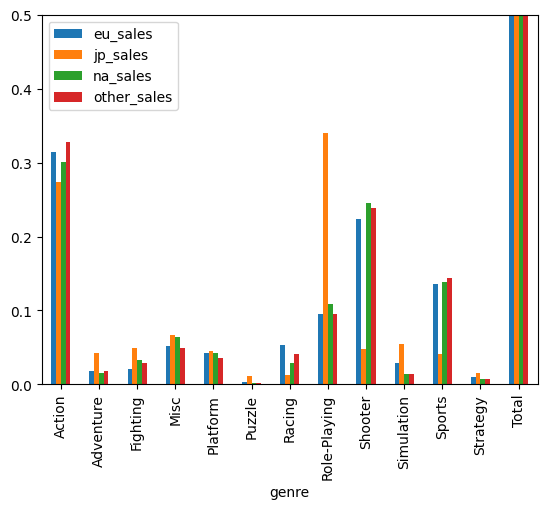

In [73]:
df_top_genre.plot(kind='bar').set_ylim([0, 0.5])

(0.0, 0.5)

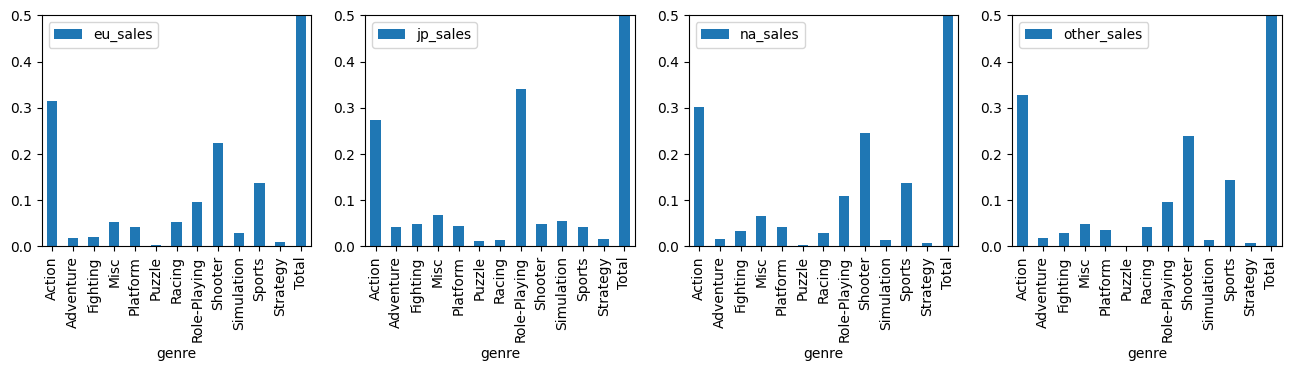

In [74]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16,3))
df_top_genre.plot(kind='bar', y='eu_sales', ax=axes[0]).set_ylim([0, 0.5])
df_top_genre.plot(kind='bar', y='jp_sales', ax=axes[1]).set_ylim([0, 0.5])
df_top_genre.plot(kind='bar', y='na_sales', ax=axes[2]).set_ylim([0, 0.5])
df_top_genre.plot(kind='bar', y='other_sales', ax=axes[3]).set_ylim([0, 0.5])

Анализ популярных жанров по регионам показал, что предпочтения пользователей Европы, Северной Америки и остального мира совпадают. Самыми популярными жанрами являются: Action, Shooter, Sports, Role-Playing, Misc.  
Япония ввиду нацианальных особенностей пользователей отличается от остального мира. Наиболее популярные жанры: Role-Playing, Action, Misc, Fighting, Shooter. Стрелялки в японии не популярны в отличие от остального мира. Также в Японии более популярны RPG, чем в остальном мире.

#### Влияние рейтинга ESRB на продажи

In [75]:
df_rating = df_actual.pivot_table(index='rating',
                      values=['na_sales','eu_sales','jp_sales','other_sales'], 
                      aggfunc='sum', margins = True, margins_name='Total')

In [76]:
df_rating

,eu_sales,jp_sales,na_sales,other_sales
rating,,,,
E,113.02,28.33,114.37,31.44
E10+,55.37,8.19,75.70,16.23
M,193.96,21.20,231.57,63.38
T,52.90,26.02,66.02,17.92
Total,415.25,83.74,487.66,128.97


In [77]:
df_rating['eu_sales'] = df_rating['eu_sales'] / df_rating.loc['Total', 'eu_sales']
df_rating['jp_sales'] = df_rating['jp_sales'] / df_rating.loc['Total', 'jp_sales']
df_rating['na_sales'] = df_rating['na_sales'] / df_rating.loc['Total', 'na_sales']
df_rating['other_sales'] = df_rating['other_sales'] / df_rating.loc['Total', 'other_sales']

In [78]:
df_rating

,eu_sales,jp_sales,na_sales,other_sales
rating,,,,
E,0.27,0.34,0.23,0.24
E10+,0.13,0.10,0.16,0.13
M,0.47,0.25,0.47,0.49
T,0.13,0.31,0.14,0.14
Total,1.00,1.00,1.00,1.00


(0.0, 0.5)

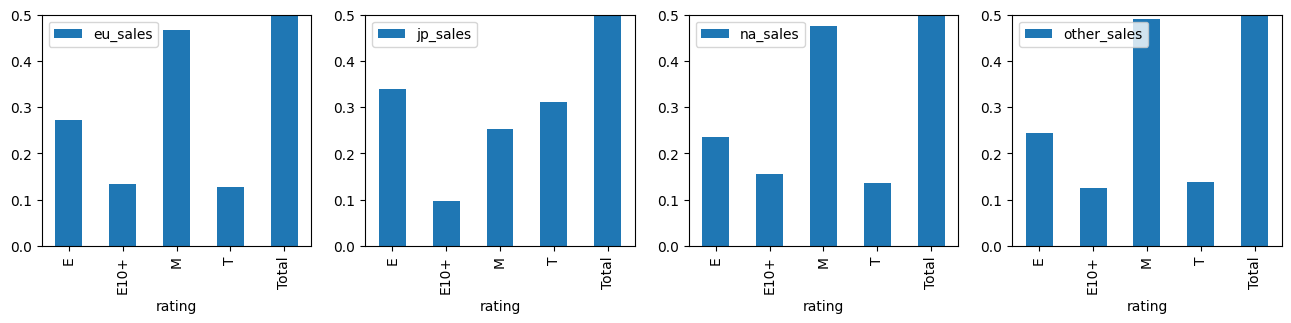

In [79]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16,3))
df_rating.plot(kind='bar', y='eu_sales', ax=axes[0]).set_ylim([0, 0.5])
df_rating.plot(kind='bar', y='jp_sales', ax=axes[1]).set_ylim([0, 0.5])
df_rating.plot(kind='bar', y='na_sales', ax=axes[2]).set_ylim([0, 0.5])
df_rating.plot(kind='bar', y='other_sales', ax=axes[3]).set_ylim([0, 0.5])

Ситуация с распределением рейтинга игр схожа с распределением жанров. Пользовтели по своим предпочтениям схожи в Европе, Северной Америке и остальном мире. Япония отличается. Рейтинг показывает нам популярность игр среди разных категорий населения.
* В Японии более популярны, чем в остальном мире, игры с рейтингом E - игры подходящие для всех возрастов с преобладаем мультяшной графики
* Также в Японии выделяется доля продаж игр для подростков (T). В остальном мире игры для подростков не так популярны.
* Самые популярные игры в Северной Америке, Европе и остальном мире - игры для совершеннолетней аудитори, на них приходится почти половина продаж. 

### Проверка гипотез

Проверка гипотезы: средние пользовательские рейтинги ('user_score') платформ Xbox One ('XOne') и PC ('PC') одинаковые

Нулевую гипотезу всегда принимаем равной исследуемому показателю

H_0: Средний пользовательский рейтинг 'XOne' = Средний пользовательский рейтинг 'PC'
H_a: Средний пользовательский рейтинг 'XOne' ≠ Средний пользовательский рейтинг 'PC'
alpha = 0.05

In [80]:
sample_1 = df_actual[(df_actual['platform'] == 'XOne') & (~df_actual['user_score'].isna())]['user_score']
sample_2 = df_actual[(df_actual['platform'] == 'PC') & (~df_actual['user_score'].isna())]['user_score']

results = st.ttest_ind(sample_1, sample_2, equal_var=False)

alpha = .05

print(results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

0.506590103051467
Не получилось отвергнуть нулевую гипотезу


Не получилось отвергнуть гипотезу, что средние пользовательские рейтинги одинаковые.

Проверка гипотезы: Средние пользовательские рейтинги ('user_score') жанров Action и Sports разные

Идет от обратного, проверяем нулевую гипотезу, что рейтинги равны, и хотим увидеть, что p-value будет меньше уровня статистической значимости

H_0: Средний пользовательский рейтинг 'Action' = Средний пользовательский рейтинг 'Sports'
H_a: Средний пользовательский рейтинг 'user_score' ≠ Средний пользовательский рейтинг 'Sports'
alpha = 0.05

In [81]:
sample_1 = df_actual[(df_actual['genre'] == 'Action') & (~df_actual['user_score'].isna())]['user_score']
sample_2 = df_actual[(df_actual['genre'] == 'Sports') & (~df_actual['user_score'].isna())]['user_score']

results = st.ttest_ind(sample_1, sample_2, equal_var=False)

alpha = .05

print(results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

5.989458066467354e-20
Отвергаем нулевую гипотезу


Нулевую гипотезу отвергаем, т.е. средние пользовательские рейтинги жанров разные.

### Общие выводы

Цель иследования заключалась в выборе для магазина компьютерных игры "Стримчик" потенциально популярных игр для инвестирования в их распространение.  Для этого было проведено исследование самых популярыных для актуального периода платформ, жанров. Популярность проверялась на основании проданных копий, т.к. не всегда оценки критиков и пользователей адекватно влияют на итоговый объем продаж игр.
* Рекомендуем сделать ставку на новые платформы такие как PS4 и XOne, которые пришли на смену "отмирающим" PS3, X360. Эти платформы будут на пике ближайшие несколько лет, до выхода нового поколения.
* Исследование показало, что в каждой платформе есть доля игр, которые будут приносить основную выручку, на рекламе которых стоит сосредоточиться. В выборе таких игр могут помочь оценки критиков, которые имеют линейную связь с продажами игр.
* Важно определиться на аудитории какого региона мы планируем сосредоточиться. Если наши продажи представлены во всех регионах, то нужно обязательно скорректировать маркетинговую компанию в соответствии с предпочтениями пользователей конкретного региона. Предпочтения связаны с определенной платформой и жанром игр, которые популярны в регионе. Например, жители японии предпочитаю мобильные платформы (3DS, PSV), в Северной америце популярна XOne, жители Европы чаще покупают платформы PS4. 
* В зависимости от региона разделяются предпочтения пользовательй по жанрам. В японии предпочитают играть в RPG и Action, в остальном мире популярны Action, Shooter, Sports.
* Если ориентироваться на весь мир в целом, но в реднем наибольший доход на игру приносят жанры Shooter, Sports, Platform, не смотря на то, что продажи Action лидирую среди игр за счет хитов.
* Не стоит забывать о возрасте целевой аудитории. Для Японии и остального мира различаются возрастные категории, среди которых игры наиболее популярны. В японии стоит сосредоточиться на продаже игр для подростков, а в остальном мире - на продажи игр для взрослой аудитории.